<h1 style="font-size-3rem;color:red;">Titanic Machine Learning from Disaster</h1>

<img src="https://images.immediate.co.uk/production/volatile/sites/7/2018/01/TIT011DJ_0-345b632.jpg?quality=90&webp=true&resize=600,400">

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("C:/Users/user/Desktop/Titanic/Data/train (1).csv")

In [4]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

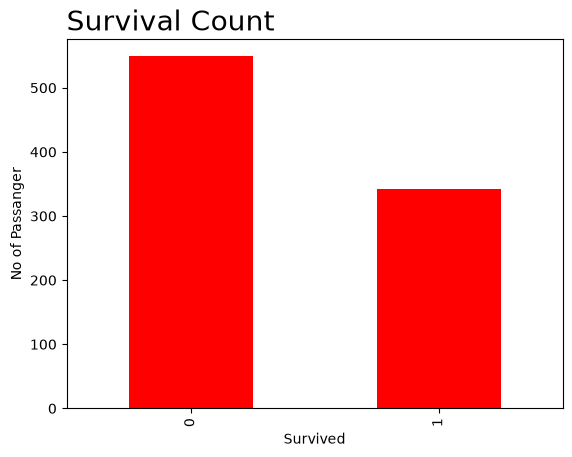

In [5]:
df['Survived'].value_counts().plot(
    kind = 'bar',
    color='red')
plt.title('Survival Count', loc='left', size=20)
plt.xlabel('Survived', size=10)
plt.ylabel('No of Passanger', size=10)
plt.show()

In [6]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

-The analysis shows that female passengers had a much higher survival rate (74.2%) than male passengers (18.9%). This suggests that sex was a strong predictor of survival in the Titanic disaster. The data alone does not explain the reason for this difference, although historical accounts often mention evacuation practices such as "women and children first."

-Female passengers had a survival rate about 55 percentage points higher than male passengers.
74.2 - 18.9 = 55.3 percentage points

In [7]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [8]:
df['Sex'].value_counts(normalize=True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [9]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [10]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

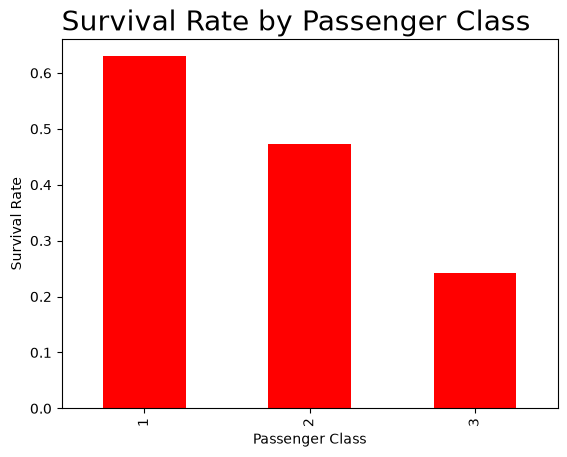

In [11]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar", color = 'red')

plt.title("Survival Rate by Passenger Class", loc = 'left', size=20)
plt.xlabel("Passenger Class", size = 10)
plt.ylabel("Survival Rate", size = 10)

plt.show()

The data shows that first-class passengers had the highest survival rate.

The analysis shows a strong relationship between passenger class and survival. First-class passengers had the highest survival rate (about 63%), while third-class passengers had the lowest (about 24%). This suggests that passenger class was an important predictor of survival.

<Axes: ylabel='Frequency'>

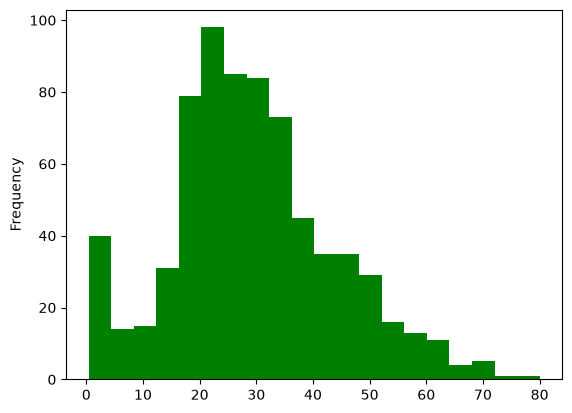

In [12]:
df['Age'].describe()
df['Age'].plot(kind = 'hist', bins=20, color = 'g')

In [13]:
min = df['Age'].min()
print(min * 12)
print(min)
df['Age'].max()

5.04
0.42


80.0

In [14]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
)
df['AgeGroup'].value_counts()
df.groupby('AgeGroup')['Survived'].mean()

AgeGroup
Child         0.579710
Teen          0.428571
Adult         0.382682
Middle Age    0.400000
Senior        0.227273
Name: Survived, dtype: float64

In [15]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle Age", "Senior"]
)

df["AgeGroup"].value_counts()

df.groupby("AgeGroup")["Survived"].mean()

AgeGroup
Child         0.579710
Teen          0.428571
Adult         0.382682
Middle Age    0.400000
Senior        0.227273
Name: Survived, dtype: float64

The analysis shows that children had the highest survival rate (about 58%), while seniors had the lowest (about 23%). This suggests that age was associated with survival on the Titanic. The dataset itself does not explain the reason for this difference.
    
    -Approximately 58% of children survived, making them the age group with the highest survival rate.

    -Senior passengers had the lowest survival rate, with only about 23% surviving.

In [16]:
##Fill up missing age
df['Age'] = df['Age'].fillna(df['Age'].median())
##Drop the Cabin Column 
df.drop("Cabin", axis=1, inplace=True)

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    str     
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Embarked     889 non-null    str     
 11  AgeGroup     714 non-null    category
dtypes: category(1), float64(2), int64(5), str(4)
memory usage: 77.8 KB


In [91]:
#encoding the sex and embarked
#sex male = 0 while female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=["Embarked"], dtype=int)

In [103]:
#Features (X) and Target (y)
y = df['Survived']
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'AgeGroup'], axis = 1)

In [105]:
#spliting X to train 80% and test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [111]:
#Creating and training of model
titanic_model = LogisticRegression(max_iter=1000)
titanic_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [115]:
#prediction
y_pred = titanic_model.predict(X_test)

In [121]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy is',accuracy)

Accuracy is 0.8100558659217877


The model correctly predicted the survival status of about 81% of the passengers in the test dataset that it had never seen before.

In [124]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [19 55]]


	Predicted Died      (0)	Predicted Survived (1)
Actually Died (0)     	90	                   15
Actually Survived (1)	19                  	55

Precision = TP / (TP + FP)
Precision = 55 / (55 + 15)
Precision = 55 / 70
Precision = 0.786

So your model's precision is about 78.6%.

What does that mean?

Out of every 100 passengers the model predicts will survive:

About 79 actually survive.
About 21 do not.

Recall = TP / (TP + FN)
Recall = 55 / (55 + 19)
Recall = 55 / 74
Recall = 0.743


Out of every 100 passengers who actually survived, the model correctly identified about 74 of them as survivors.

The remaining 26 are the passengers the model missed (the False Negatives).

In [128]:
f1 = f1_score(y_test, y_pred)

print(f'f1 score',f1)

f1 score 0.7638888888888888
